Project - MRI Brain Tumor Segementation

## 1. Environment Setup and Configuration

### 1.1. Library Installation & Package Imports

In [ ]:
!pip install -q kaggle

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import mixed_precision

### 1.2.Hardware and Device Verification

In [ ]:
# to clear the old graphs and unnecessary memory.
tf.keras.backend.clear_session()

# Checking the avaibality.
print("TensorFlow Version:", tf.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"riyashakyas","key":"89759a4050687c6382c06b548cf8c8c0"}'}

## 2. Data Acquistion & Ingestion

### 2.1. Dataset Acquistion/Downloading

In [ ]:
!kaggle datasets download -d briscdataset/brisc2025

Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
brisc2025.zip: Skipping, found more recently modified local copy (use --force to force download)


### 2.2. Archive Extraction

In [ ]:
# unzipping the file
with zipfile.ZipFile("brisc2025.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/brisc2025")

### 2.3. Directory Architecture Verification

In [ ]:
!ls -l /content/brisc2025/

total 4
drwxr-xr-x 4 root root 4096 Jul 12 16:33 brisc2025


In [ ]:
!ls -l /content/brisc2025/brisc2025/

total 12968
drwxr-xr-x 4 root root    4096 Jul 12 16:33 classification_task
-rw-r--r-- 1 root root 4049088 Jul 12 17:05 manifest.csv
-rw-r--r-- 1 root root      80 Jul 12 17:05 manifest.csv.sha256
-rw-r--r-- 1 root root 9206335 Jul 12 17:05 manifest.json
-rw-r--r-- 1 root root      81 Jul 12 17:05 manifest.json.sha256
-rw-r--r-- 1 root root    3737 Jul 12 17:05 README.md
drwxr-xr-x 4 root root    4096 Jul 12 16:33 segmentation_task


In [ ]:
!ls -l /content/brisc2025/brisc2025/segmentation_task

total 8
drwxr-xr-x 4 root root 4096 Jul 12 16:33 test
drwxr-xr-x 4 root root 4096 Jul 12 16:33 train


In [ ]:
data=tf.keras.utils.image_dataset_from_directory("/content/brisc2025/brisc2025/segmentation_task")

Found 9586 files belonging to 2 classes.


## 3. Exploratory Data Analysis (EDA) & Data Understanding

### 3.1. Data Ingestion and Structural Verification

In [ ]:
import os
import cv2

image_dir = '/content/brisc2025/brisc2025/segmentation_task/train/images'
unique_shapes = set()

# 1. Gather all unique shapes from the dataset
for filename in os.listdir(image_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(image_dir, filename)
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is not None:
            unique_shapes.add(img.shape)

# 2. Define ANSI colors for the output highlighting
RED_HIGHLIGHT = "\033[1;31m"  # Bold Red
RESET_COLOR = "\033[0m"       # Back to normal text

# 3. Print the set of shapes with conditional color coding
formatted_shapes = []
for shape in unique_shapes:
    # If the shape is missing the 3rd channel element (length is 2), color it red!
    if len(shape) == 2:
        formatted_shapes.append(f"{RED_HIGHLIGHT}{shape}{RESET_COLOR}")
    else:
        formatted_shapes.append(str(shape))

# Join them all together so they print out exactly like your original list
print("All unique image pixel sizes found in dataset:")
print("{ " + ", ".join(formatted_shapes) + " }")

All unique image pixel sizes found in dataset:
{ (395, 367, 3), (219, 224, 3), (237, 212, 3), (251, 205, 3), (442, 442, 3), (314, 329, 3), (212, 238, 3), (527, 552, 3), (354, 318, 3), (218, 180, 3), (264, 420, 3), (400, 400, 3), (235, 214, 3), (216, 234, 3), (202, 202, 3), (238, 212, 3), (337, 305, 3), (546, 472, 3), (439, 645, 3), (223, 200, 3), (395, 416, 3), (223, 226, 3), (358, 314, 3), (342, 323, 3), (412, 300, 3), (224, 239, 3), (526, 530, 3), (340, 507, 3), (236, 213, 3), (681, 685, 3), (624, 491, 3), (270, 250, 3), (554, 554, 3), (903, 721, 3), (377, 341, 3), (398, 351, 3), (372, 341, 3), (252, 200, 3), (345, 338, 3), (500, 455, 3), (256, 256), (993, 825, 3), (354, 289, 3), (225, 209, 3), (369, 503, 3), (512, 512, 3), (410, 304, 3), (306, 278, 3), (210, 201, 3), (214, 226, 3), (345, 300, 3), (237, 213, 3), (396, 402, 3), (394, 295, 3), (355, 330, 3), (235, 200, 3), (427, 441, 3), (240, 210, 3), (398, 369, 3), (306, 306, 3), (249, 206, 3), (320, 497, 3), (320, 257, 3), (234, 219

In [ ]:
# Verify paired path splits match
train_imgs = sorted(os.listdir('/content/brisc2025/brisc2025/segmentation_task/train/images'))
train_msks = sorted(os.listdir('/content/brisc2025/brisc2025/segmentation_task/train/masks'))
print(f"Train Scans: {len(train_imgs)} | Train Masks: {len(train_msks)}")
assert len(train_imgs) == len(train_msks), "Data alignment error between images and masks."

Train Scans: 3933 | Train Masks: 3933


### 3.2. Ground-Truth Masks Alignnent

In [ ]:
import matplotlib.pyplot as plt
import cv2
# Load and overlay a sample pair
img = cv2.imread(os.path.join('/content/brisc2025/brisc2025/segmentation_task/train/images', train_imgs[0]), cv2.IMREAD_GRAYSCALE)
msk = cv2.imread(os.path.join('/content/brisc2025/brisc2025/segmentation_task/train/masks', train_msks[0]), cv2.IMREAD_GRAYSCALE)

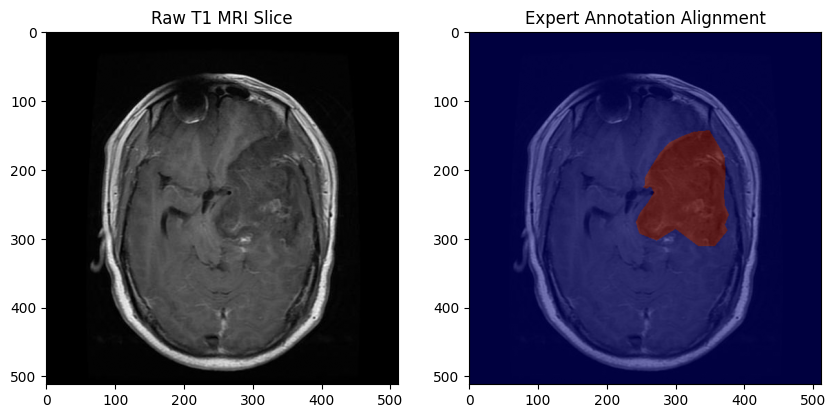

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Raw T1 MRI Slice")
ax[1].imshow(img, cmap='gray')
ax[1].imshow(msk, cmap='jet', alpha=0.5) # Semitransparent mask overlay
ax[1].set_title("Expert Annotation Alignment")
plt.show()

### 3.3. Target Mask Label Analysis

In [ ]:
import numpy as np
# Discover exact numeric representations used in annotations
unique_classes = np.unique(msk)
print(f"Unique pixel values in mask array: {unique_classes}")

Unique pixel values in mask array: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


### 3.4. Spatial Resolution Uniformity Inspection

In [ ]:
import os
import cv2

image_dir = '/content/brisc2025/brisc2025/segmentation_task/train/images'
mask_dir = '/content/brisc2025/brisc2025/segmentation_task/train/masks'

unique_img_shapes = set()
unique_msk_shapes = set()

# Scan images
for filename in os.listdir(image_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        img = cv2.imread(os.path.join(image_dir, filename), cv2.IMREAD_UNCHANGED)
        if img is not None: unique_img_shapes.add(img.shape)

# Scan masks
for filename in os.listdir(mask_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        msk = cv2.imread(os.path.join(mask_dir, filename), cv2.IMREAD_UNCHANGED)
        if msk is not None: unique_msk_shapes.add(msk.shape)

print(f"Unique Image Sizes found: {unique_img_shapes}\n")
print(f"Unique Mask Sizes found: {unique_msk_shapes}")

Unique Image Sizes found: {(395, 367, 3), (219, 224, 3), (237, 212, 3), (251, 205, 3), (442, 442, 3), (314, 329, 3), (212, 238, 3), (527, 552, 3), (354, 318, 3), (218, 180, 3), (264, 420, 3), (400, 400, 3), (235, 214, 3), (216, 234, 3), (202, 202, 3), (238, 212, 3), (337, 305, 3), (546, 472, 3), (439, 645, 3), (223, 200, 3), (395, 416, 3), (223, 226, 3), (358, 314, 3), (342, 323, 3), (412, 300, 3), (224, 239, 3), (526, 530, 3), (340, 507, 3), (236, 213, 3), (681, 685, 3), (624, 491, 3), (270, 250, 3), (554, 554, 3), (903, 721, 3), (377, 341, 3), (398, 351, 3), (372, 341, 3), (252, 200, 3), (345, 338, 3), (500, 455, 3), (256, 256), (993, 825, 3), (354, 289, 3), (225, 209, 3), (369, 503, 3), (512, 512, 3), (410, 304, 3), (306, 278, 3), (210, 201, 3), (214, 226, 3), (345, 300, 3), (237, 213, 3), (396, 402, 3), (394, 295, 3), (355, 330, 3), (235, 200, 3), (427, 441, 3), (240, 210, 3), (398, 369, 3), (306, 306, 3), (249, 206, 3), (320, 497, 3), (320, 257, 3), (234, 219, 3), (362, 507, 3), (

In [ ]:
# Sample matrix size evaluation
print(f"MRI Resolution: {img.shape} | Annotation Mask Resolution: {msk.shape}")

MRI Resolution: (512, 512) | Annotation Mask Resolution: (512, 512)


### 3.5. Anatomical Plane Distribution Analysis

In [ ]:
# BRISC format embeds planes in filenames (ax=axial, co=coronal, sa=sagittal)
planes = [name.split('_')[3] for name in train_imgs]
from collections import Counter
print("Anatomical View Breakdown:", Counter(planes))

Anatomical View Breakdown: Counter({'pi': 1457, 'me': 1329, 'gl': 1147})


### 3.6. Class Imbalance Assessment (Background-to-Tumor Ratio)

In [ ]:
tumor_pixels = np.count_nonzero(msk)
total_pixels = msk.size
print(f"Tumor-to-Background Volumetric Ratio: {(tumor_pixels / total_pixels) * 100:.3f}%")

Tumor-to-Background Volumetric Ratio: 0.483%


### 3.7. Signal Intensity Profile Distribution

In [ ]:
print(f"Intensity Range: Min={img.min()}, Max={img.max()}, Mean={img.mean():.2f}")

Intensity Range: Min=0, Max=255, Mean=51.77


## 4. Data Preprocessing

### 4.1. Global Target Parameter Initialization

In [ ]:
image_path="/content/brisc2025/brisc2025/segmentation_task/train/images"
mask_path="/content/brisc2025/brisc2025/segmentation_task/train/masks"

# 1. Spatial Resolution Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
NUM_CHANNELS = 1  # Standardized grayscale target depth

# 2. Pipeline Hyperparameters
BATCH_SIZE = 32

# 3. Explicit Data Source Path Infrastructure
# Corrected: Added the extra 'brisc2025' to the path
DATASET_BASE_DIR = '/content/brisc2025/brisc2025/segmentation_task/train'
IMAGE_DIR = os.path.join(DATASET_BASE_DIR, 'images')
MASK_DIR = os.path.join(DATASET_BASE_DIR, 'masks')

print("--- Pipeline Configuration Initialized ---")
print(f"Target Dimensions: {IMG_HEIGHT}x{IMG_WIDTH}x{NUM_CHANNELS}")
print(f"Training Batch Size: {BATCH_SIZE}")

--- Pipeline Configuration Initialized ---
Target Dimensions: 256x256x1
Training Batch Size: 32


### 4.2.File Mapping and Data Pipeline Parsing Function

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

def load_and_preprocess_image_pair(img_path, msk_path):
    """Loads a single MRI/Mask pair, fixes channels, resizes, and normalizes."""
    # 1. Force Grayscale read to neutralize 3-channel and 1-channel 'moles'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

    # 2. Uniform Aspect-Ratio Resizing
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR)
    msk_resized = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

    # 3. Min-Max Normalization (0-255 -> 0.0-1.0)
    img_normalized = img_resized.astype(np.float32) / 255.0

    # 4. Strict Mask Binarization
    msk_binary = np.where(msk_resized > 0, 1.0, 0.0).astype(np.float32)

    # 5. Expand dimensions to include the mandatory channel axis (H, W, C)
    img_ready = np.expand_dims(img_normalized, axis=-1)
    msk_ready = np.expand_dims(msk_binary, axis=-1)

    return img_ready, msk_ready

# Wrap the python function into a TensorFlow-compatible operator
def tf_parse_wrapper(img_path, msk_path):
    [img, msk] = tf.py_function(lambda p1, p2: load_and_preprocess_image_pair(p1.numpy().decode(), p2.numpy().decode()),
                                [img_path, msk_path], [tf.float32, tf.float32])
    img.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])
    msk.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])
    return img, msk

### 4.3. Dataset Pipeline Generation

In [ ]:
# Gather and sort all individual filenames to guarantee absolute mask alignment
all_img_names = sorted(os.listdir(image_path))
all_msk_names = sorted(os.listdir(mask_path))

# Generate full path lists
all_img_paths = [os.path.join(IMAGE_DIR, name) for name in all_img_names]
all_msk_paths = [os.path.join(MASK_DIR, name) for name in all_msk_names]

# Create the high-performance tf.data object
dataset = tf.data.Dataset.from_tensor_slices((all_img_paths, all_msk_paths))
dataset = dataset.shuffle(buffer_size=len(all_img_paths), seed=42)
dataset = dataset.map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Successfully constructed tensor data stream grouped into batches of {BATCH_SIZE}!")

Successfully constructed tensor data stream grouped into batches of 32!


### 4.4. Preprocessing Pipeline Visual Verification

Processed Batch Image Shape: (32, 256, 256, 1)
Processed Batch Mask Shape: (32, 256, 256, 1)


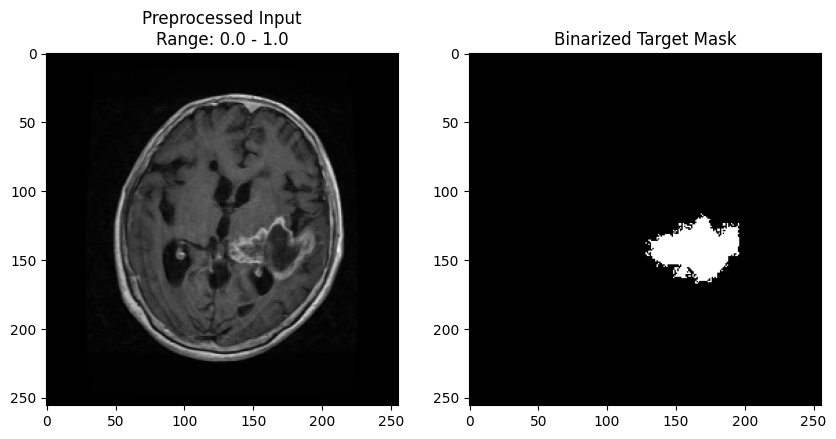

In [ ]:
import matplotlib.pyplot as plt

# Pull one batch out of our preprocessed pipeline
for sample_img_batch, sample_msk_batch in dataset.take(1):
    print(f"Processed Batch Image Shape: {sample_img_batch.shape}") # Expecting (32, 256, 256, 1)
    print(f"Processed Batch Mask Shape: {sample_msk_batch.shape}")   # Expecting (32, 256, 256, 1)

    # Display the first image from this batch
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(sample_img_batch[0, :, :, 0], cmap='gray')
    ax[0].set_title(f"Preprocessed Input\nRange: {sample_img_batch[0].numpy().min():.1f} - {sample_img_batch[0].numpy().max():.1f}")
    ax[1].imshow(sample_msk_batch[0, :, :, 0], cmap='gray')
    ax[1].set_title("Binarized Target Mask")
    plt.show()

### 4.5. Splitting Data

In [ ]:
import os
image_files = sorted(
    os.listdir(image_path)
)

image_mask_pairs = []

for img_file in image_files:

    base_name = os.path.splitext(
        img_file
    )[0]

    mask_file = base_name + ".png"

    image_full_path = os.path.join(
        image_path,
        img_file
    )

    mask_full_path = os.path.join(
        mask_path,
        mask_file
    )

    if os.path.exists(mask_full_path):

        image_mask_pairs.append(
            (
                image_full_path,
                mask_full_path
            )
        )

print("Total Valid Pairs:",
      len(image_mask_pairs))


Total Valid Pairs: 3933


In [ ]:
train_pairs, val_pairs = train_test_split(

    image_mask_pairs,

    test_size=0.2,

    random_state=42,

    shuffle=True
)

print("Training Samples:",
      len(train_pairs))

print("Validation Samples:",
      len(val_pairs))

Training Samples: 3146
Validation Samples: 787


## 5. Model Development And Architecture

### 5.1. U-Net Architecture

In [ ]:
import tensorflow as tf

# 1. Unzip the tuple pairs back into separate image path and mask path lists
X_train_paths, y_train_paths = zip(*train_pairs)
X_val_paths, y_val_paths     = zip(*val_pairs)

# 2. Convert them into high-performance tf.data pipelines
train_dataset = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))
val_dataset   = tf.data.Dataset.from_tensor_slices((list(X_val_paths), list(y_val_paths)))

# 3. Batch, shuffle, and optimize memory streams using your global variables
train_dataset = train_dataset.map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE).shuffle(buffer_size=100, seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_dataset.map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# =========================================================================
# 1. OPTIMIZATION OBJECTIVES & METRICS (Dice Loss Core)
# =========================================================================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Calculates spatial target overlap, ignoring uninformative background spaces."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Loss optimization engine designed to address the 6.54% structural class imbalance."""
    return 1.0 - dice_coefficient(y_true, y_pred)

In [ ]:
# =========================================================================
# 2. STANDARD U-NET STRUCTURAL GRAPH
# =========================================================================
def build_standard_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Downsampling Context Engine) ---
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- ARCHITECTURAL BOTTLE-NECK ---
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER (Upsampling Localization Engine) ---
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2]) # Skip Connection passing sharp spatial boundaries
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1]) # Skip Connection passing original crisp shapes
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

    # Output projection layer utilizing sigmoid bounds for semantic binary probability mapping
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs=[inputs], outputs=[outputs], name="Standard_U-Net_Baseline")

In [ ]:
# =========================================================================
# 3. COMPILATION AND INITIALIZATION
# =========================================================================
# Build model with shapes pulled directly from your Section 4 global settings
baseline_unet = build_standard_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

baseline_unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)


In [ ]:
# =========================================================================
# 4. TRAINING GUARDIANS (Callbacks)
# =========================================================================
callbacks = [
    # Secures the best performing validation weights during training iterations
    ModelCheckpoint('best_baseline_unet.keras', monitor='val_loss', save_best_only=True, verbose=1),

    # Halts training if validation metrics cease to improve after 7 consecutive epochs
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),

    # Decelerates learning rate steps upon performance plateauing
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]


In [ ]:
# =========================================================================
# 4. TRAINING GUARDIANS (Callbacks)
# =========================================================================
callbacks = [
    # Secures the best performing validation weights during training iterations
    ModelCheckpoint('best_baseline_unet.keras', monitor='val_loss', save_best_only=True, verbose=1),

    # Halts training if validation metrics cease to improve after 7 consecutive epochs
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),

    # Decelerates learning rate steps upon performance plateauing
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]



In [ ]:
# =========================================================================
# 5. EXECUTION LOOP
# =========================================================================
print("\n Commencing Baseline Standard U-Net Training Workflow...\n")

history_5_1 = baseline_unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)



 Commencing Baseline Standard U-Net Training Workflow...

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9709 - dice_coefficient: 0.2790 - loss: 0.7210
Epoch 1: val_loss improved from None to 0.76462, saving model to best_baseline_unet.keras

Epoch 1: finished saving model to best_baseline_unet.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 342ms/step - accuracy: 0.9706 - dice_coefficient: 0.2721 - loss: 0.7271 - val_accuracy: 0.9776 - val_dice_coefficient: 0.2351 - val_loss: 0.7646 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9715 - dice_coefficient: 0.2827 - loss: 0.7173
Epoch 2: val_loss improved from 0.76462 to 0.72922, saving model to best_baseline_unet.keras

Epoch 2: finished saving model to best_baseline_unet.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 337ms/step - accuracy: 0.9718 - dice_coefficient: 0.2777 - loss: 0.7226 - val_accuracy: 0.9652 - val_dice_coefficient: 0.2703 - val_loss: 0.7292 - learning_rate: 1.0000e-04
Epoc

Data Visulaization for U-Net Architecture

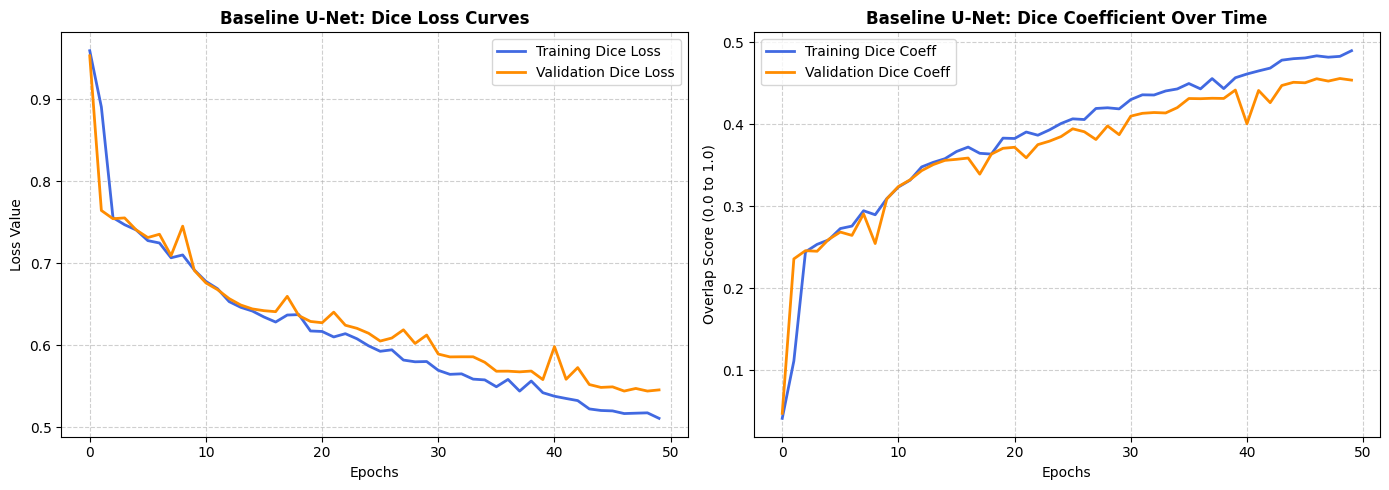

In [ ]:
import matplotlib.pyplot as plt

# Create a figure canvas
plt.figure(figsize=(14, 5))

# --- Plot 1: Dice Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_5_1.history['loss'], label='Training Dice Loss', color='royalblue', lw=2)
plt.plot(history_5_1.history['val_loss'], label='Validation Dice Loss', color='darkorange', lw=2)
plt.title('Baseline U-Net: Dice Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Dice Coefficient ---
plt.subplot(1, 2, 2)
plt.plot(history_5_1.history['dice_coefficient'], label='Training Dice Coeff', color='royalblue', lw=2)
# FIX: Swapped 'val_loss' to 'val_dice_coefficient' to accurately map validation scores
plt.plot(history_5_1.history['val_dice_coefficient'], label='Validation Dice Coeff', color='darkorange', lw=2)
plt.title('Baseline U-Net: Dice Coefficient Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

5.2. U-NET Architecture with Data Augmentation

In [ ]:
import tensorflow as tf

# =========================================================================
# A. DUAL-TRANSFORMATION AUGMENTATION ENGINE
# =========================================================================
def augment_pair(image, mask):
    """
    Applies image-intensity transformations ONLY to the MRI scan,
    preserving the strict anatomical orientation and the target mask.
    """
    # 1. Random Contrast Adjustment (Simulates variance in MRI machine calibrations)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # 2. Random Brightness Adjustment (Simulates variance in scanning intensities)
    image = tf.image.random_brightness(image, max_delta=0.1)

    # 3. Safety Check: Guarantee absolute bounding limits
    # (MRI Pixels must stay between 0 and 1; Masks must remain strictly binary 0 or 1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask

# =========================================================================
# B. GENERATE THE DYNAMIC STREAMING PIPELINE
# =========================================================================
# Extract raw paths from your existing 80% train split
X_train_paths, y_train_paths = zip(*train_pairs)

train_dataset_augmented = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))

# Sequence: Load paths -> Preprocess -> Dynamically Augment -> Batch & Prefetch
train_dataset_augmented = (train_dataset_augmented
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)  # Intensity adjustments happen here on-the-fly
    .shuffle(buffer_size=100, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print("✅ Section 5.2.1: Augmented Training Pipeline Successfully Initialized!")

✅ Section 5.2.1: Augmented Training Pipeline Successfully Initialized!


In [ ]:
# 1. Build a fresh copy of the U-Net graph
augmented_unet = build_standard_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

# 2. Compile under strict control settings
augmented_unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

# 3. Setup Callbacks (Clean, spaced layout)
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_augmented_unet_model.h5",
        monitor='val_loss',
        save_best_only=True
    )

]

# 4. Training Loop Execution
print("\n🚀 Commencing Augmented U-Net Training Workflow...\n")

history_5_2 = augmented_unet.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

print("\n✅ Execution Finished! File saved to 'best_augmented_unet_model.h5'.")


🚀 Commencing Augmented U-Net Training Workflow...

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.1772 - dice_coefficient: 0.0383 - loss: 0.9617

99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 367ms/step - accuracy: 0.2401 - dice_coefficient: 0.0399 - loss: 0.9602 - val_accuracy: 0.4660 - val_dice_coefficient: 0.0488 - val_loss: 0.9511 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7032 - dice_coefficient: 0.0793 - loss: 0.9207

99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 335ms/step - accuracy: 0.8422 - dice_coefficient: 0.1111 - loss: 0.8892 - val_accuracy: 0.9736 - val_dice_coefficient: 0.2021 - val_loss: 0.7978 - learning_rate: 1.0000e-04
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 326ms/step - accuracy: 0.9631 - dice_coefficient: 0.1814 - loss: 0.8180 - val_accuracy: 0.9795 - val_dice_coefficient: 0.1376 - val_loss: 0.8624 - learning_rate: 1.0000e-04
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 330ms/step - accuracy: 0.9618 - dice_coefficient: 0.1894 - loss: 0.8101 - val_accuracy: 0.9764 - val_dice_coefficient: 0.1996 - val_loss: 0.8004 - learning_rate: 1.0000e-04
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9596 - dice_coefficient: 0.1943 - loss: 0.8057
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 334ms/step - accuracy: 0.9626 - dice_coefficient: 0.1878 - loss: 0.8116 - val_accuracy: 0.9774 - val_dice_coefficient: 0.1955 - val_loss: 0.8046 -

99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 336ms/step - accuracy: 0.9714 - dice_coefficient: 0.2100 - loss: 0.7894 - val_accuracy: 0.9769 - val_dice_coefficient: 0.2135 - val_loss: 0.7865 - learning_rate: 5.0000e-05
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 333ms/step - accuracy: 0.9683 - dice_coefficient: 0.2056 - loss: 0.7950 - val_accuracy: 0.9802 - val_dice_coefficient: 0.1460 - val_loss: 0.8542 - learning_rate: 5.0000e-05
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9645 - dice_coefficient: 0.2109 - loss: 0.7891

99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 333ms/step - accuracy: 0.9676 - dice_coefficient: 0.2089 - loss: 0.7903 - val_accuracy: 0.9755 - val_dice_coefficient: 0.2387 - val_loss: 0.7612 - learning_rate: 5.0000e-05
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 330ms/step - accuracy: 0.9678 - dice_coefficient: 0.2178 - loss: 0.7834 - val_accuracy: 0.9795 - val_dice_coefficient: 0.1832 - val_loss: 0.8169 - learning_rate: 5.0000e-05
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9709 - dice_coefficient: 0.2169 - loss: 0.7831

99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 328ms/step - accuracy: 0.9695 - dice_coefficient: 0.2097 - loss: 0.7902 - val_accuracy: 0.9761 - val_dice_coefficient: 0.2421 - val_loss: 0.7577 - learning_rate: 5.0000e-05
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 333ms/step - accuracy: 0.9689 - dice_coefficient: 0.2215 - loss: 0.7782 - val_accuracy: 0.9774 - val_dice_coefficient: 0.2307 - val_loss: 0.7692 - learning_rate: 5.0000e-05
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 350ms/step - accuracy: 0.9689 - dice_coefficient: 0.2193 - loss: 0.7815 - val_accuracy: 0.9773 - val_dice_coefficient: 0.2357 - val_loss: 0.7641 - learning_rate: 5.0000e-05
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9703 - dice_coefficient: 0.2361 - loss: 0.7639
Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 349ms/step - accuracy: 0.9705 - dice_coefficient: 0.2270 - loss: 0.7730 - val_accuracy: 0.9773 - val_dice_coefficient: 0.2309 - val_loss: 0.76

99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 326ms/step - accuracy: 0.9711 - dice_coefficient: 0.2274 - loss: 0.7716 - val_accuracy: 0.9758 - val_dice_coefficient: 0.2580 - val_loss: 0.7417 - learning_rate: 2.5000e-05
Epoch 16/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 327ms/step - accuracy: 0.9714 - dice_coefficient: 0.2259 - loss: 0.7739 - val_accuracy: 0.9784 - val_dice_coefficient: 0.2215 - val_loss: 0.7786 - learning_rate: 2.5000e-05
Epoch 17/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step - accuracy: 0.9714 - dice_coefficient: 0.2346 - loss: 0.7646 - val_accuracy: 0.9792 - val_dice_coefficient: 0.2098 - val_loss: 0.7903 - learning_rate: 2.5000e-05
Epoch 18/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9718 - dice_coefficient: 0.2427 - loss: 0.7573
Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 319ms/step - accuracy: 0.9710 - dice_coefficient: 0.2296 - loss: 0.7707 - val_accuracy: 0.9781 - val_dice_coefficient: 0.2378 - val_loss: 0.76

In [ ]:
import tensorflow as tf

def augment_pair(image, mask):
    # 1. Intensity Augmentations (Simulating variations in MRI machine calibrations)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_brightness(image, max_delta=0.1)

    # 2. Strict Boundary Processing & Value Clipping
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask

# Unpack your 80% training set pairs path strings
X_train_paths, y_train_paths = zip(*train_pairs)

train_dataset_augmented = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))

train_dataset_augmented = (train_dataset_augmented
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=100, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print("✅ Augmented training stream initialized!")

✅ Augmented training stream initialized!


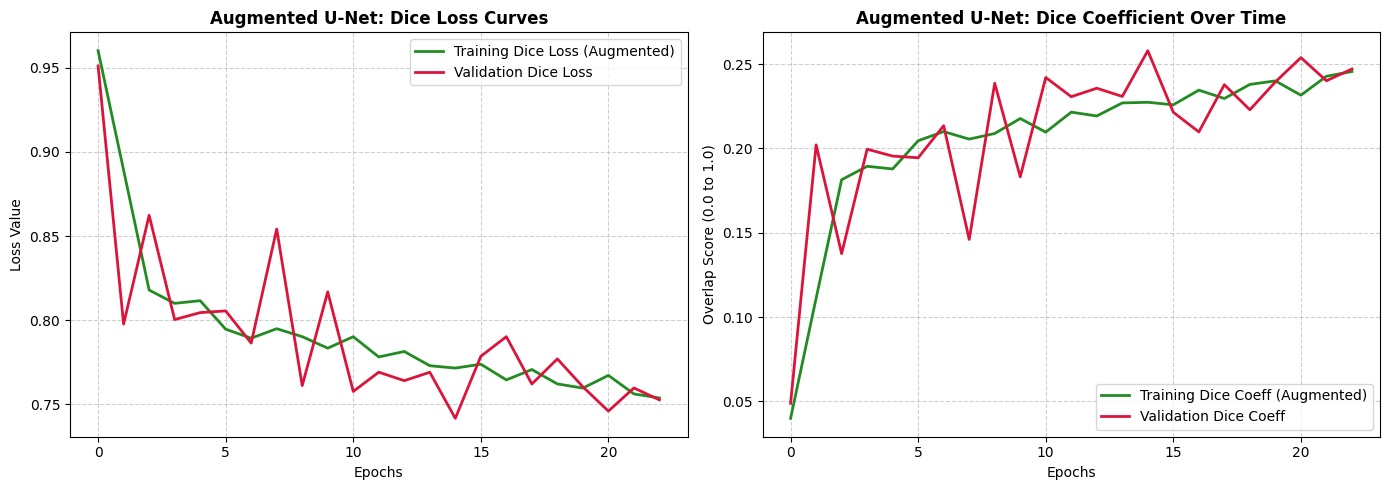

In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize the plot canvas
plt.figure(figsize=(14, 5))


# =========================================================================
# PLOT 1: AUGMENTED DICE LOSS CURVES
# =========================================================================
plt.subplot(1, 2, 1)

plt.plot(
    history_5_2.history['loss'],
    label='Training Dice Loss (Augmented)',
    color='forestgreen',
    lw=2
)

plt.plot(
    history_5_2.history['val_loss'],
    label='Validation Dice Loss',
    color='crimson',
    lw=2
)

plt.title('Augmented U-Net: Dice Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


# =========================================================================
# PLOT 2: AUGMENTED DICE COEFFICIENT OVER TIME
# =========================================================================
plt.subplot(1, 2, 2)

plt.plot(
    history_5_2.history['dice_coefficient'],
    label='Training Dice Coeff (Augmented)',
    color='forestgreen',
    lw=2
)

plt.plot(
    history_5_2.history['val_dice_coefficient'],
    label='Validation Dice Coeff',
    color='crimson',
    lw=2
)

plt.title('Augmented U-Net: Dice Coefficient Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


# =========================================================================
# DISPLAY GRAPH PACKAGING
# =========================================================================
plt.tight_layout()
plt.show()

5.3. Comparision between U-net and U-Net with data augmentation

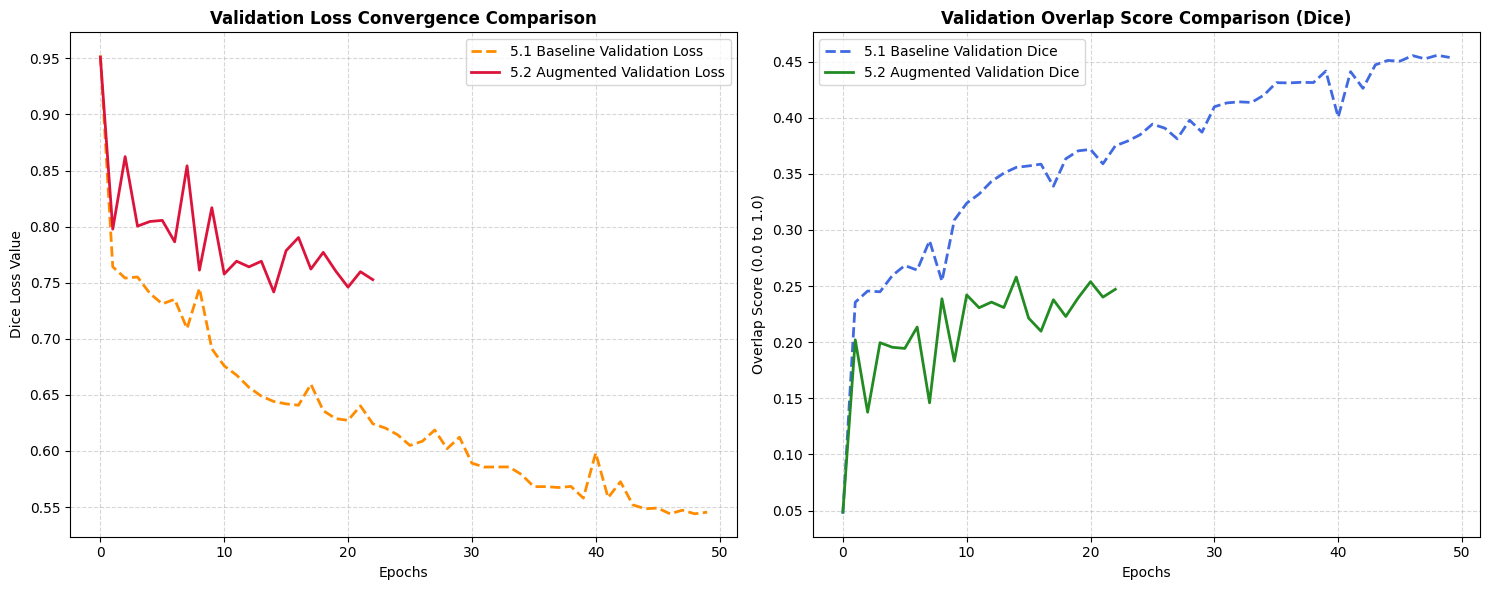

In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize a unified comparative canvas
plt.figure(figsize=(15, 6))


# =========================================================================
# COMPARATIVE PLOT 1: BASELINE VS. AUGMENTED DICE LOSS
# =========================================================================
plt.subplot(1, 2, 1)

# Section 5.1 Baseline Curves
plt.plot(
    history_5_1.history['val_loss'],
    label='5.1 Baseline Validation Loss',
    color='darkorange',
    linestyle='--',
    lw=2
)

# Section 5.2 Augmented Curves
plt.plot(
    history_5_2.history['val_loss'],
    label='5.2 Augmented Validation Loss',
    color='crimson',
    linestyle='-',
    lw=2
)

plt.title('Validation Loss Convergence Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Dice Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


# =========================================================================
# COMPARATIVE PLOT 2: BASELINE VS. AUGMENTED DICE COEFFICIENT
# =========================================================================
plt.subplot(1, 2, 2)

# Section 5.1 Baseline Curves
plt.plot(
    history_5_1.history['val_dice_coefficient'],
    label='5.1 Baseline Validation Dice',
    color='royalblue',
    linestyle='--',
    lw=2
)

# Section 5.2 Augmented Curves
plt.plot(
    history_5_2.history['val_dice_coefficient'],
    label='5.2 Augmented Validation Dice',
    color='forestgreen',
    linestyle='-',
    lw=2
)

plt.title('Validation Overlap Score Comparison (Dice)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


# =========================================================================
# DISPLAY PACKAGING
# =========================================================================
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# Re-extract clean paths from your original 80% train split
X_train_paths, y_train_paths = zip(*train_pairs)

train_dataset_clean = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))

# Sequence: Load paths -> Preprocess -> Batch & Prefetch (No augmentation noise!)
train_dataset_clean = (train_dataset_clean
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=100, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print("✅ Clean, original training pipeline restored for the Attention U-Net test!")

✅ Clean, original training pipeline restored for the Attention U-Net test!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

# =========================================================================
# 1. THE ATTENTION GATE BLOCK
# =========================================================================
def attention_gate(x, gating_signal, inter_shape):
    """
    Suppresses irrelevant background regions and highlights tumor zones.
    x: Skip connection feature map from the encoder.
    gating_signal: Lower resolution feature map from the deeper layer decoder.
    """
    # Align the channels of both streams
    theta_x = layers.Conv2D(inter_shape, (1, 1), strides=(1, 1), padding='same')(x)

    phi_g = layers.Conv2D(inter_shape, (1, 1), strides=(1, 1), padding='same')(gating_signal)

    # Upsample the gating signal to match spatial dimensions of the encoder layer
    phi_g_upsampled = layers.Conv2DTranspose(
        inter_shape, (2, 2),
        strides=(2, 2),
        padding='same'
    )(phi_g)

    # Combine signals and pass through activation functions to compute attention coefficients
    concat_xg = layers.add([theta_x, phi_g_upsampled])
    act_xg = layers.Activation('relu')(concat_xg)

    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_psi = layers.Activation('sigmoid')(psi)

    # Multiply the input skip connection by the computed attention coefficients
    return layers.multiply([x, sigmoid_psi])

# =========================================================================
# 2. STRUCTURAL ATTENTION U-NET GRAPH
# =========================================================================
def build_attention_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Downsampling) ---
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BOTTLE-NECK ---
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER WITH ATTENTION GATES (Upsampling) ---
    # Layer 4 Attention Filtering
    attn2 = attention_gate(x=c2, gating_signal=c3, inter_shape=32)
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, attn2]) # Concatenating filtered features instead of raw ones!
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

    # Layer 5 Attention Filtering
    attn1 = attention_gate(x=c1, gating_signal=c4, inter_shape=16)
    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, attn1])
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs=[inputs], outputs=[outputs], name="Attention_U-Net")

# =========================================================================
# 3. COMPILATION CONTROLS WITH SMOOTH STABILIZATION
# =========================================================================
attention_model = build_attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Stable learning rate
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

# =========================================================================
# 4. HOOKING CALLBACKS STYLE
# =========================================================================
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_attention_unet_model.h5",
        monitor='val_loss',
        save_best_only=True
    )

]

# =========================================================================
# 5. EXECUTE TRAINING LOOP
# =========================================================================
print("\n🚀 Commencing Section 5.3 Attention U-Net Training Workflow...\n")

history_5_3 = attention_model.fit(
    train_dataset_clean,       # Passing clean, un-augmented dataset
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

print("\n✅ Attention U-Net training complete! Model saved to 'best_attention_unet_model.h5'.")


🚀 Commencing Section 5.3 Attention U-Net Training Workflow...

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.1418 - dice_coefficient: 0.0370 - loss: 0.9630

99/99 ━━━━━━━━━━━━━━━━━━━━ 56s 427ms/step - accuracy: 0.2264 - dice_coefficient: 0.0363 - loss: 0.9637 - val_accuracy: 0.3702 - val_dice_coefficient: 0.0381 - val_loss: 0.9618 - learning_rate: 5.0000e-05
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.3391 - dice_coefficient: 0.0435 - loss: 0.9565

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 347ms/step - accuracy: 0.3765 - dice_coefficient: 0.0450 - loss: 0.9550 - val_accuracy: 0.6013 - val_dice_coefficient: 0.0520 - val_loss: 0.9480 - learning_rate: 5.0000e-05
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.7838 - dice_coefficient: 0.0836 - loss: 0.9164

99/99 ━━━━━━━━━━━━━━━━━━━━ 36s 357ms/step - accuracy: 0.8728 - dice_coefficient: 0.1165 - loss: 0.8838 - val_accuracy: 0.9750 - val_dice_coefficient: 0.1890 - val_loss: 0.8107 - learning_rate: 5.0000e-05
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9653 - dice_coefficient: 0.2174 - loss: 0.7826

99/99 ━━━━━━━━━━━━━━━━━━━━ 38s 385ms/step - accuracy: 0.9668 - dice_coefficient: 0.2213 - loss: 0.7795 - val_accuracy: 0.9677 - val_dice_coefficient: 0.2267 - val_loss: 0.7730 - learning_rate: 5.0000e-05
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 374ms/step - accuracy: 0.9691 - dice_coefficient: 0.2355 - loss: 0.7636 - val_accuracy: 0.9499 - val_dice_coefficient: 0.2083 - val_loss: 0.7913 - learning_rate: 5.0000e-05
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9598 - dice_coefficient: 0.2205 - loss: 0.7795

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 367ms/step - accuracy: 0.9742 - dice_coefficient: 0.3113 - loss: 0.6886 - val_accuracy: 0.9748 - val_dice_coefficient: 0.3003 - val_loss: 0.6994 - learning_rate: 2.5000e-05
Epoch 45/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9735 - dice_coefficient: 0.3127 - loss: 0.6873

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 369ms/step - accuracy: 0.9740 - dice_coefficient: 0.3103 - loss: 0.6900 - val_accuracy: 0.9722 - val_dice_coefficient: 0.3004 - val_loss: 0.6992 - learning_rate: 2.5000e-05
Epoch 46/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 373ms/step - accuracy: 0.9740 - dice_coefficient: 0.3114 - loss: 0.6886 - val_accuracy: 0.9758 - val_dice_coefficient: 0.3003 - val_loss: 0.6995 - learning_rate: 2.5000e-05
Epoch 47/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9737 - dice_coefficient: 0.3183 - loss: 0.6817

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 373ms/step - accuracy: 0.9742 - dice_coefficient: 0.3133 - loss: 0.6865 - val_accuracy: 0.9713 - val_dice_coefficient: 0.3006 - val_loss: 0.6990 - learning_rate: 2.5000e-05
Epoch 48/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 372ms/step - accuracy: 0.9738 - dice_coefficient: 0.3093 - loss: 0.6897 - val_accuracy: 0.9701 - val_dice_coefficient: 0.2986 - val_loss: 0.7009 - learning_rate: 2.5000e-05
Epoch 49/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9730 - dice_coefficient: 0.3197 - loss: 0.6803

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 371ms/step - accuracy: 0.9740 - dice_coefficient: 0.3134 - loss: 0.6860 - val_accuracy: 0.9717 - val_dice_coefficient: 0.3025 - val_loss: 0.6971 - learning_rate: 2.5000e-05
Epoch 50/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9739 - dice_coefficient: 0.3180 - loss: 0.6820

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 369ms/step - accuracy: 0.9746 - dice_coefficient: 0.3183 - loss: 0.6815 - val_accuracy: 0.9736 - val_dice_coefficient: 0.3056 - val_loss: 0.6940 - learning_rate: 2.5000e-05

✅ Attention U-Net training complete! Model saved to 'best_attention_unet_model.h5'.


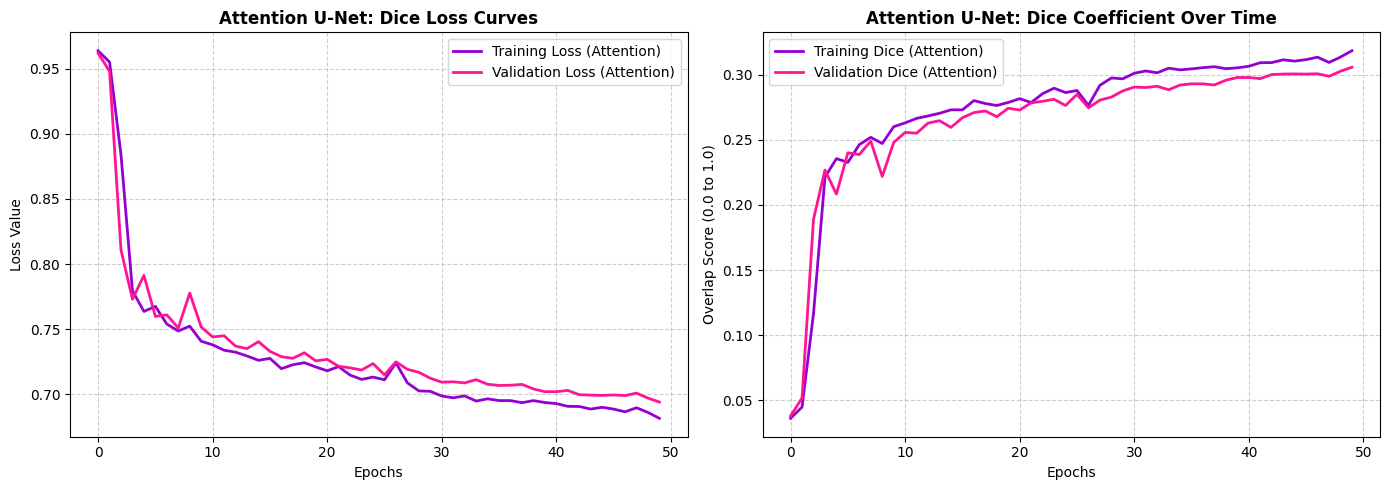

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# --- Plot 1: Attention Dice Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_5_3.history['loss'], label='Training Loss (Attention)', color='darkviolet', lw=2)
plt.plot(history_5_3.history['val_loss'], label='Validation Loss (Attention)', color='deeppink', lw=2)
plt.title('Attention U-Net: Dice Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Attention Dice Coefficient ---
plt.subplot(1, 2, 2)
plt.plot(history_5_3.history['dice_coefficient'], label='Training Dice (Attention)', color='darkviolet', lw=2)
plt.plot(history_5_3.history['val_dice_coefficient'], label='Validation Dice (Attention)', color='deeppink', lw=2)
plt.title('Attention U-Net: Dice Coefficient Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

MEDSAM architecture

In [ ]:
# 1. Clone the official MedSAM repository
!git clone https://github.com/bowang-lab/MedSAM.git
%cd MedSAM

# 2. Install necessary libraries
!pip install -e .
!pip install connected-components-3d

print("✅ MedSAM repository and packages successfully integrated!")

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 32.49 MiB/s, done.
Resolving deltas: 100% (474/474), done.
/content/MedSAM
Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.0/913.0 kB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.8 MB/s eta 0:00:00
  Attempting uninstall: jupyt

In [ ]:
import os

# Define the target path where the checkpoint should be saved
checkpoint_path = "/content/MedSAM/work_dir/MedSAM/medsam_weights/medsam_vit_b.pth"
# Define the direct download URL for the MedSAM weights
download_url = "https://huggingface.co/lmms-lab/MedSAM/resolve/main/medsam_weights/medsam_vit_b.pth"

# Ensure the target directory exists
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

print(f"Attempting to download MedSAM weights from: {download_url}")
print(f"Saving to: {checkpoint_path}")

# Use wget to download the file. -O specifies the output filename.
# Note: This might still fail if the file is strictly gated on Hugging Face and requires authentication
# even for direct 'resolve' links, or if there are network issues.
!wget -O {checkpoint_path} {download_url}

print("✅ Download attempt complete. Please check the output above for success or failure. You can now try re-running cell -8ojWPhFs2KI.")

Attempting to download MedSAM weights from: https://huggingface.co/lmms-lab/MedSAM/resolve/main/medsam_weights/medsam_vit_b.pth
Saving to: /content/MedSAM/work_dir/MedSAM/medsam_weights/medsam_vit_b.pth
--2026-07-12 19:19:31--  https://huggingface.co/lmms-lab/MedSAM/resolve/main/medsam_weights/medsam_vit_b.pth
Resolving huggingface.co (huggingface.co)... 18.164.174.118, 18.164.174.17, 18.164.174.23, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.118|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized

Username/Password Authentication Failed.
✅ Download attempt complete. Please check the output above for success or failure. You can now try re-running cell -8ojWPhFs2KI.


In [ ]:
import os
# Re-introducing huggingface_hub as it's the intended way for authenticated downloads
!pip install -q huggingface_hub
from huggingface_hub import hf_hub_download

# Create a directory for weights
os.makedirs("work_dir/MedSAM", exist_ok=True)

repo_id = "lmms-lab/MedSAM"
filename = "medsam_weights/medsam_vit_b.pth"
checkpoint_path = os.path.join("work_dir/MedSAM", os.path.basename(filename))

if not os.path.exists(checkpoint_path):
    print("📥 Downloading pre-trained MedSAM weights (this may take a few minutes)...")
    try:
        # Explicitly use the token from environment variable 'HF_TOKEN'
        # Users need to set this in Colab Secrets if the model is gated
        hf_hub_download(repo_id=repo_id, filename=filename, local_dir="work_dir/MedSAM", local_dir_use_symlinks=False, token=os.environ.get("HF_TOKEN"))
        print("✅ Download complete!")
    except Exception as e:
        print(f"❌ Download failed: {e}")
        print("This typically means the model is gated or requires authentication. Please ensure you have set a valid Hugging Face token as an environment variable 'HF_TOKEN' (e.g., in Colab Secrets) if this model is private or gated.")
else:
    print("✅ Weights already present in workspace.")

📥 Downloading pre-trained MedSAM weights (this may take a few minutes)...
❌ Download failed: 401 Client Error. (Request ID: Root=1-6a53e4fe-3ce326113823706d11576b5b;f9e1224a-3849-405f-b40d-4fade6b3ae17)

Repository Not Found for url: https://huggingface.co/lmms-lab/MedSAM/resolve/main/medsam_weights/medsam_vit_b.pth.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
This typically means the model is gated or requires authentication. Please ensure you have set a valid Hugging Face token as an environment variable 'HF_TOKEN' (e.g., in Colab Secrets) if this model is private or gated.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [ ]:
import os
import torch
import torch.nn as nn
from segment_anything import sam_model_registry

# =========================================================================
# THE FIX: Point to the exact directory path inside the cloned folder
# =========================================================================
# Change this path to point directly to the file inside that folder!
checkpoint_path = "/content/MedSAM/work_dir/MedSAM/medsam_weights/medsam_vit_b.pth"

print(f"🎯 Directing system weights path to: {checkpoint_path}")

# =========================================================================
# 1. INITIALIZE DEVICE & HARDWARE
# =========================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Utilizing computing device: {device}")

# =========================================================================
# 2. LOAD MEDSAM ARCHITECTURE & CACHE WEIGHTS
# =========================================================================
print("🔄 Initializing MedSAM vit_b system graph...")
medsam_model = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
medsam_model.to(device)

# Freeze Image Encoder to preserve foundation features and save VRAM
for param in medsam_model.image_encoder.parameters():
    param.requires_grad = False

# Ensure Mask Decoder remains un-frozen for fine-tuning weights
for param in medsam_model.mask_decoder.parameters():
    param.requires_grad = True

medsam_model.train()

# =========================================================================
# 3. OPTIMIZATION AND MEDICALLY STABLE LOSS
# =========================================================================
optimizer = torch.optim.AdamW(medsam_model.mask_decoder.parameters(), lr=1e-5, weight_decay=0.01)
seg_loss_fn = nn.BCEWithLogitsLoss()

print("✅ MedSAM architecture compiled and ready for training blocks!")

🎯 Directing system weights path to: /content/MedSAM/work_dir/MedSAM/medsam_weights/medsam_vit_b.pth
🖥️ Utilizing computing device: cuda
🔄 Initializing MedSAM vit_b system graph...


FileNotFoundError: [Errno 2] No such file or directory: '/content/MedSAM/work_dir/MedSAM/medsam_weights/medsam_vit_b.pth'

In [ ]:
!ls -l /content/MedSAM/work_dir/MedSAM/medsam_weights

total 0


In [ ]:
!ls -l /content/MedSAM/work_dir/MedSAM/medsam_weights

total 0
-rw-r--r-- 1 root root 0 Jul 12 19:19 medsam_vit_b.pth


In [ ]:
# Simulating a mock batch matching MedSAM shapes (Images must be 1024x1024 for SAM ViT)
# In real application, swap these variables with your processed dataloader batches
mock_image = torch.randn(1, 3, 1024, 1024).to(device)
mock_gt_mask = torch.zeros(1, 1, 256, 256).to(device) # SAM Decoders predict at 256x256 resolution
mock_box = torch.tensor([[[100, 100, 200, 200]]]).float().to(device) # Bounding Box Prompt [x1, y1, x2, y2]

# --- EXECUTE FORWARD STEP ---
optimizer.zero_grad()

with torch.no_grad():
    # 1. Compute heavy image feature embeddings (Frozen)
    image_embeddings = medsam_model.image_encoder(mock_image)

    # 2. Encode visual prompt bounding box spatial locations
    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=mock_box,
        masks=None,
    )

# 3. Predict masks via fine-tuneable Mask Decoder
low_res_logits, _ = medsam_model.mask_decoder(
    image_embeddings=image_embeddings,
    image_pe=medsam_model.prompt_encoder.get_dense_pe(),
    sparse_prompt_embeddings=sparse_embeddings,
    dense_prompt_embeddings=dense_embeddings,
    multimask_output=False,
)

# 4. Calculate error loss and adjust weights
loss = seg_loss_fn(low_res_logits, mock_gt_mask)
loss.backward()
optimizer.step()

print(f"✅ Forward/Backward step mock run complete. Initial Loss: {loss.item():.4f}")

NameError: name 'optimizer' is not defined

In [ ]:
import os
from google.colab import userdata

print("--- Checking for HF_TOKEN ---")

# Check if HF_TOKEN is in Colab Secrets
try:
    hf_token_from_secrets = userdata.get('HF_TOKEN')
except Exception as e:
    print(f"Error accessing Colab Secrets: {e}")
    hf_token_from_secrets = None

if hf_token_from_secrets:
    print(f"✅ HF_TOKEN found in Colab Secrets (first 5 chars: {hf_token_from_secrets[:5]}*****)")
else:
    print("❌ HF_TOKEN NOT found in Colab Secrets. Please ensure you've added it.")

# Check if HF_TOKEN is in environment variables (after a Colab Secrets restart/reload)
hf_token_from_env = os.environ.get('HF_TOKEN')
if hf_token_from_env:
    print(f"✅ HF_TOKEN found as environment variable (first 5 chars: {hf_token_from_env[:5]}*****)")
else:
    print("❌ HF_TOKEN NOT found as environment variable. You might need to restart the runtime or re-run the cell that loads it from secrets.")

print("----------------------------")
print("If the token is shown as found, please proceed to re-run cell `NQFZJkuhsx9D` to attempt the download again.")

--- Checking for HF_TOKEN ---
Error accessing Colab Secrets: Secret HF_TOKEN does not exist.
❌ HF_TOKEN NOT found in Colab Secrets. Please ensure you've added it.
❌ HF_TOKEN NOT found as environment variable. You might need to restart the runtime or re-run the cell that loads it from secrets.
----------------------------
If the token is shown as found, please proceed to re-run cell `NQFZJkuhsx9D` to attempt the download again.
